In [6]:
import sys
from pathlib import Path

repo_root = Path.cwd()

sys.path.insert(0, str(repo_root / 'prob_cGAN_for_GEO_QPE/src'))
import prob_cGAN as pcgan
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings('ignore', message='facecolor will have no effect')

# Set up variables
model_path = repo_root / 'prob_cGAN_for_GEO_QPE/model' / 'generator.pth'
config = pcgan.load_config(str(repo_root / 'prob_cGAN_for_GEO_QPE/model' / 'config.yaml'))
selected_channels = config['data']['selected_channels']
n_lat,n_lon = 164,280
prev_time = config['data']['prev_time']
a = config['data']['a']

In [7]:
'''
# Load data
ds_input_target = xr.open_zarr('/bg/data/mergosat/data/input_target_AMJ2019.zarr/')
ds_input_target = ds_input_target.isel(time=slice(2490, 2490+4*6))
input = ds_input_target['seviri input'].values
target= ds_input_target['radklim-yw'].values
lon = ds_input_target['LON'].values
lat = ds_input_target['LAT'].values
time = ds_input_target['time'].values
ds_input_target2 = xr.open_zarr('/bg/data/mergosat/data/input_target_JAS2019.zarr/')
ds_input_target2 = ds_input_target2.isel(time=slice(3130, 3130+4*6))
time2 = ds_input_target2['time'].values
input2 = ds_input_target2['seviri input'].values
target2= ds_input_target2['radklim-yw'].values
#combine the two datasets
input = np.concatenate((input, input2), axis=0)
target = np.concatenate((target, target2), axis=0)
time = np.concatenate((time, time2), axis=0)
del ds_input_target, ds_input_target2, time2, input2, target2

# pdir now for 28.4.2019 and 2.8.2019
ds_pdir_now = xr.open_zarr('/bg/data/mergosat/data/pdir_now_aligned_JAS2019.zarr/')
ds_pdir_now = ds_pdir_now.isel(**{'time hr': slice(782, 782+6)})
pdir_now2 = ds_pdir_now['pdir_nowhmark'].values
lon_pdir_now = ds_pdir_now['LON'].values
lat_pdir_now = ds_pdir_now['LAT'].values
time_pdir_now2 = ds_pdir_now['time hr'].values
ds_pdir_now = xr.open_zarr('/bg/data/mergosat/data/pdir_now_aligned_AMJ2019.zarr/')
ds_pdir_now = ds_pdir_now.isel(**{'time hr': slice(623, 623+6)})
time_pdir_now = ds_pdir_now['time hr'].values
pdir_now = ds_pdir_now['pdir_nowhmark'].values


#combine the two datasets
pdir_now = np.concatenate((pdir_now, pdir_now2), axis=0)
time_pdir_now = np.concatenate((time_pdir_now, time_pdir_now2), axis=0)
del ds_pdir_now, time_pdir_now2, pdir_now2


# save as zarr in data
ds_combined = xr.Dataset(
    {
        'pdir_now': (('time_hr', 'x', 'y'), pdir_now, {'units': 'mm/h', 'long_name': 'regridded PDIR-Now hourly precipitation'}),
        'radklim-yw': (('time', 'x', 'y'), target, {'units': 'mm/5min', 'long_name': 'regridded RADKLIM-YW radar rainfall amounts'}),
        'seviri_channels_norm': (('time', 'channel', 'tstep', 'x', 'y'), input, {'units': '1', 'long_name': 'Normalized SEVIRI brightness temperature'}),
        'lat': (('x', 'y'), lat, {'units': 'degrees_north', 'long_name': 'Latitude'}),
        'lon': (('x', 'y'), lon, {'units': 'degrees_east', 'long_name': 'Longitude'}),
    },
    coords={'time_hr': time_pdir_now, 'time': time},
    attrs={
        'description': 'Combined dataset for input, target, benchmark, including pdir_now and seviri channels'
    }
)
# if not empty overwrite
ds_combined.to_zarr('/bg/home/janner-s/prob_cGAN_for_GEO_QPE/data/input_target_benchmark.zarr', mode='w')

print(f'size of combined dataset in MB: {ds_combined.nbytes / 1e6:.2f} MB')'''


"\n# Load data\nds_input_target = xr.open_zarr('/bg/data/mergosat/data/input_target_AMJ2019.zarr/')\nds_input_target = ds_input_target.isel(time=slice(2490, 2490+4*6))\ninput = ds_input_target['seviri input'].values\ntarget= ds_input_target['radklim-yw'].values\nlon = ds_input_target['LON'].values\nlat = ds_input_target['LAT'].values\ntime = ds_input_target['time'].values\nds_input_target2 = xr.open_zarr('/bg/data/mergosat/data/input_target_JAS2019.zarr/')\nds_input_target2 = ds_input_target2.isel(time=slice(3130, 3130+4*6))\ntime2 = ds_input_target2['time'].values\ninput2 = ds_input_target2['seviri input'].values\ntarget2= ds_input_target2['radklim-yw'].values\n#combine the two datasets\ninput = np.concatenate((input, input2), axis=0)\ntarget = np.concatenate((target, target2), axis=0)\ntime = np.concatenate((time, time2), axis=0)\ndel ds_input_target, ds_input_target2, time2, input2, target2\n\n# pdir now for 28.4.2019 and 2.8.2019\nds_pdir_now = xr.open_zarr('/bg/data/mergosat/data/

In [8]:
# load the combined dataset
ds_combined = xr.open_zarr('/bg/home/janner-s/prob_cGAN_for_GEO_QPE/data/input_target_benchmark.zarr')
pdir_now = ds_combined['pdir_now'].values
target = ds_combined['radklim-yw'].values
input = ds_combined['seviri_channels_norm'].values
lon = ds_combined['lon'].values
lat = ds_combined['lat'].values
time = ds_combined['time'].values
time_pdir_now = ds_combined['time_hr'].values
print('Information about the loaded dataset:')
print(f'size of loaded dataset in MB: {(ds_combined.nbytes) / 1e6:.2f} MB')
print(f'shape of input: {input.shape}, dtype: {input.dtype}')
print(f'shape of target: {target.shape}, dtype: {target.dtype}')
print(f'shape of pdir_now: {pdir_now.shape}, dtype: {pdir_now.dtype}')
print(f'shape of lon: {lon.shape}, dtype: {lon.dtype}')
print(f'shape of lat: {lat.shape}, dtype: {lat.dtype}')
print(f'shape of time: {time.shape}, dtype: {time.dtype}')
print(f'shape of time_pdir_now: {time_pdir_now.shape}, dtype: {time_pdir_now.dtype} (start of accum hour)')


target_norm = pcgan.norm_precip(target,a)

# Predict with cGAN
ds = pcgan.Custom_Dataset(x=input, y=target_norm)
data_loader = DataLoader(dataset=ds, batch_size=100, shuffle=False)
generator =  pcgan.Unet_ensemble_3D_alldropout(T_in=config.model.in_time,in_channels=config.model.in_channels,in_features_G=config.model.in_features_G,dropout_cfg=config.dropout).cpu()
members = 1
predictions=np.empty((members,len(target_norm),n_lat,n_lon))
print
for i in tqdm(range(members)):
    predictions_norm,_,_ = pcgan.calc_prediction(generator,model_path,data_loader,seed=1+i)
    predictions[i] = pcgan.reverse_norm_precip(predictions_norm,a).squeeze()


Information about the loaded dataset:
size of loaded dataset in MB: 49.23 MB
shape of input: (48, 2, 2, 164, 280), dtype: float32
shape of target: (48, 164, 280), dtype: float32
shape of pdir_now: (12, 164, 280), dtype: float64
shape of lon: (164, 280), dtype: float64
shape of lat: (164, 280), dtype: float64
shape of time: (48,), dtype: datetime64[ns]
shape of time_pdir_now: (12,), dtype: datetime64[ns] (start of accum hour)


  0%|                                                     | 0/1 [00:00<?, ?it/s]/bg/home/janner-s/prob_cGAN_for_GEO_QPE/src/prob_cGAN.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment

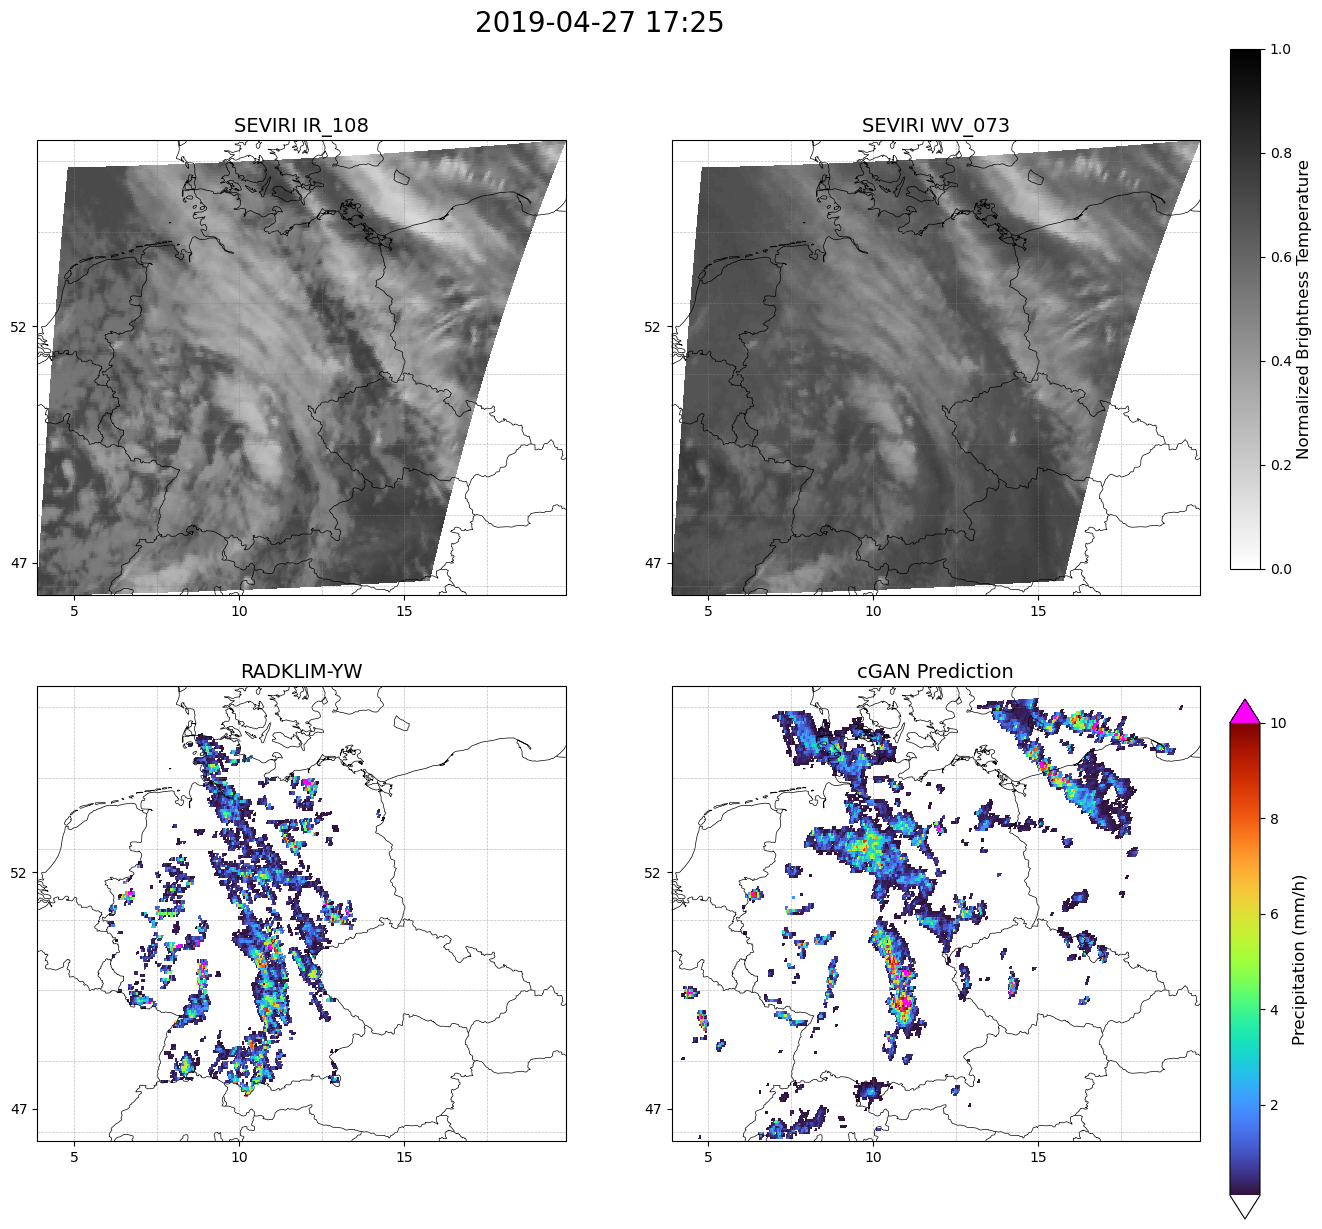

In [ ]:
turbo_custom = plt.get_cmap('turbo')
# To set the under color to empty (no color), use 'none'
turbo_custom.set_under('none')
turbo_custom.set_over('magenta')
turbo_custom.set_bad('lightgray', alpha=0.3)

proj = ccrs.PlateCarree()

for index_example in np.arange(1, len(target), step=8):
    fig, ax = plt.subplots(2,2, figsize=(15,13), subplot_kw={'projection': proj})

    p1=ax[0,0].pcolor(lon,lat,input[index_example,0,0], cmap='gray_r',vmin=0, vmax=1)
    ax[0,0].set_title(f'SEVIRI {selected_channels[1]}')
    ax[0,0].title.set_fontsize(14)
    ax[0,1].set_title(f'SEVIRI {selected_channels[2]}')
    ax[0,1].title.set_fontsize(14)
    ax[0,1].pcolor(lon,lat,input[index_example,1,0], cmap='gray_r',vmin=0, vmax=1)

    ax[1,0].set_title('RADKLIM-YW')
    ax[1,0].title.set_fontsize(14)
    p2=ax[1,0].pcolor(lon,lat,target[index_example]*12, cmap=turbo_custom, vmin=0.1, vmax=10)

    ax[1,1].set_title('cGAN Prediction')
    ax[1,1].title.set_fontsize(14)
    ax[1,1].pcolor(lon,lat,predictions[0,index_example]*12, cmap=turbo_custom, vmin=0.1, vmax=10)

    # iterate over axes to add features
    for i in range(2):
        for j in range(2):
            ax[i,j].add_feature(cfeature.BORDERS,color='k', linewidth=0.5)
            ax[i,j].add_feature(cfeature.COASTLINE,color='k', linewidth=0.5)

            ax[i,j].set_aspect('auto')

            ax[i,j].set_xticks(np.arange(5,20,5))
            ax[i,j].set_yticks(np.arange(47,55,5))
            ax[i,j].set_xticklabels(np.arange(5,20,5))
            ax[i,j].set_yticklabels(np.arange(47,55,5))

            gridlines = ax[i,j].gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.suptitle(
        f"{time[index_example].astype(str).replace('T', ' ')[:16]}",
        fontsize=20
    )

    # Add colorbar for the precipitation plots
    cbar_ax = fig.add_axes([0.92, 0.05, 0.02, 0.4])  # [left, bottom, width, height]
    cbar = fig.colorbar(p2, cax=cbar_ax,extend='both')
    cbar.set_label('Precipitation (mm/h)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    # add colorbar for the SEVIRI plots
    cbar_ax2 = fig.add_axes([0.92, 0.55, 0.02, 0.4])  #[left, bottom, width, height]
    cbar2 = fig.colorbar(p1, cax=cbar_ax2)
    cbar2.set_label('Normalized Brightness Temperature', fontsize=12)
    cbar2.ax.tick_params(labelsize=10)

In [ ]:
# hourly target and prediction
target_hr = pcgan.calculate_hourly_precip(time, target)
predictions_hr = pcgan.calculate_hourly_precip(time, predictions)

AttributeError: module 'matplotlib.pyplot' has no attribute 'sgtitle'

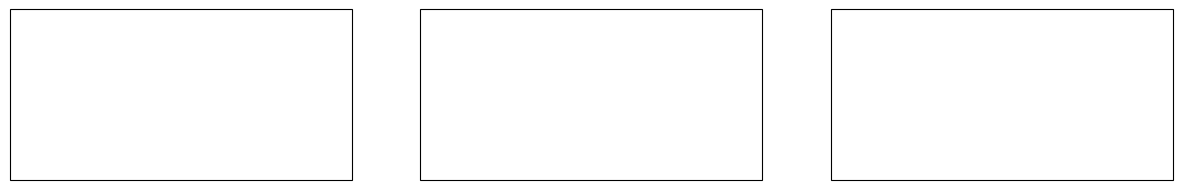

In [ ]:
for index_example in np.arange(1,len(target), step=8):
    fig,axs = plt.subplots(1,3, figsize=(15,5), subplot_kw={'projection': proj})

    plt.sgtitle(f"{time[index_example].astype(str).replace('T', ' ')[:16]} (until +1h)", fontsize=16)

    axs[0].set_title(F'RADKLIM-YW ')
    axs[0].title.set_fontsize(14)
    p2=axs[0].pcolor(lon,lat,target_hr[index_example], cmap=turbo_custom, vmin=0.1, vmax=10)

    axs[1].set_title(F'cGAN ')
    axs[1].title.set_fontsize(14)
    axs[1].pcolor(lon,lat,np.where(target_hr[index_example]>0, predictions_hr[0,index_example], np.nan), cmap=turbo_custom, vmin=0.1, vmax=10)

    axs[2].set_title(F'pPDIR-Now')
    axs[2].title.set_fontsize(14)
    axs[2].pcolor(lon, lat, np.where(target_hr[index_example]>0, pdir_now[index_example], np.nan), cmap=turbo_custom, vmin=0.1, vmax=10)

    # iterate over axes to add features
    for i in range(3):
        axs[i].add_feature(cfeature.BORDERS,color='k', linewidth=0.5)
        axs[i].add_feature(cfeature.COASTLINE,color='k', linewidth=0.5)

        axs[i].set_aspect('auto')

        axs[i].set_xticks(np.arange(5.5,15.5,5))
        axs[i].set_yticks(np.arange(48,53,5))
        axs[i].set_xticklabels(np.arange(5.5,15.5,5))
        axs[i].set_yticklabels(np.arange(48,53,5))

        gridlines = axs[i].gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
